<div style="display: flex; justify-content: center;">
  <img src=image.png
       style="width: 100%; height: auto; border-radius:10px; background-color:#f0f0f0;">
</div>

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
Unsupervised Traffic Accident Analysis Using PCA and DBSCAN
</h1>
</div>

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
IMPORT LIBRARIES
</h1>
</div>


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
import skfuzzy as fuzz
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\GCE\Downloads\traffic_accidents_5000_rows.csv")
df

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,04/22/2018 08:55:00 PM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,3.0,0.0,0.0,3.0,0.0,1.0,20,1,4
4996,04/12/2022 09:58:00 PM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,DIVIDED - W/MEDIAN BARRIER,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,21,3,4
4997,06/29/2019 03:43:00 PM,STOP SIGN/FLASHER,CLEAR,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,"REPORTED, NOT EVIDENT",1.0,0.0,0.0,0.0,1.0,1.0,15,7,6
4998,01/07/2024 11:45:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,11,1,1


In [3]:
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

In [4]:
df.shape

(5000, 24)

In [5]:
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   crash_date                     5000 non-null   object 
 1   traffic_control_device         5000 non-null   object 
 2   weather_condition              5000 non-null   object 
 3   lighting_condition             5000 non-null   object 
 4   first_crash_type               5000 non-null   object 
 5   trafficway_type                5000 non-null   object 
 6   alignment                      5000 non-null   object 
 7   roadway_surface_cond           5000 non-null   object 
 8   road_defect                    5000 non-null   object 
 9   crash_type                     5000 non-null   object 
 10  intersection_related_i         5000 non-null   object 
 11  damage                         5000 non-null   object 
 12  prim_contributory_cause        5000 non-null   o

In [7]:
df.drop(['crash_date',
    'injuries_total',
    'injuries_fatal',
    'injuries_incapacitating',
    'injuries_non_incapacitating',
    'injuries_reported_not_evident',
    'injuries_no_indication',
    'road_defect'],axis=1,inplace=True)
df

,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,crash_hour,crash_day_of_week,crash_month
0,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",UNABLE TO DETERMINE,2,NO INDICATION OF INJURY,13,7,7
1,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",IMPROPER TURNING/NO SIGNAL,2,NO INDICATION OF INJURY,0,1,8
2,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",FOLLOWING TOO CLOSELY,3,NO INDICATION OF INJURY,10,5,12
3,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",UNABLE TO DETERMINE,2,NONINCAPACITATING INJURY,19,4,8
4,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,2,NO INDICATION OF INJURY,14,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",IMPROPER OVERTAKING/PASSING,2,NONINCAPACITATING INJURY,20,1,4
4996,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,DIVIDED - W/MEDIAN BARRIER,STRAIGHT AND LEVEL,DRY,INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",DISREGARDING OTHER TRAFFIC SIGNS,2,NONINCAPACITATING INJURY,21,3,4
4997,STOP SIGN/FLASHER,CLEAR,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,INJURY AND / OR TOW DUE TO CRASH,Y,$500 OR LESS,FAILING TO YIELD RIGHT-OF-WAY,2,"REPORTED, NOT EVIDENT",15,7,6
4998,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,NOT DIVIDED,STRAIGHT AND LEVEL,WET,INJURY AND / OR TOW DUE TO CRASH,Y,$500 OR LESS,DISREGARDING TRAFFIC SIGNALS,2,NONINCAPACITATING INJURY,11,1,1


In [8]:
df.describe(include="object")

,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,crash_type,intersection_related_i,damage,prim_contributory_cause,most_severe_injury
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,15,10,6,16,20,6,7,2,2,3,37,5
top,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",UNABLE TO DETERMINE,NO INDICATION OF INJURY
freq,3006,3877,3217,1631,1743,4849,3647,2882,4749,3518,1452,3757


<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
ENCODING
</h1>
</div>


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()
categorical_cols=['intersection_related_i', 'damage', 'prim_contributory_cause', 'prim_contributory_cause','most_severe_injury','traffic_control_device',"weather_condition","lighting_condition","first_crash_type","trafficway_type","alignment","roadway_surface_cond","crash_type"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df

,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,crash_hour,crash_day_of_week,crash_month
0,12,1,3,15,8,3,5,1,1,1,33,2,2,13,7,7
1,12,1,1,15,6,3,0,1,1,2,23,2,2,0,1,8
2,12,1,3,10,15,3,0,1,1,1,18,3,2,10,5,12
3,12,1,3,0,6,3,0,0,1,2,33,2,3,19,4,8
4,12,1,3,10,15,3,5,1,1,1,11,2,2,14,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,12,1,1,14,8,3,0,0,1,2,22,2,3,20,1,4
4996,12,1,1,15,3,3,0,0,1,2,3,2,3,21,3,4
4997,11,1,3,8,8,3,0,0,1,0,17,2,4,15,7,6
4998,12,1,3,0,8,3,6,0,1,0,6,2,3,11,1,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   traffic_control_device   5000 non-null   int64
 1   weather_condition        5000 non-null   int64
 2   lighting_condition       5000 non-null   int64
 3   first_crash_type         5000 non-null   int64
 4   trafficway_type          5000 non-null   int64
 5   alignment                5000 non-null   int64
 6   roadway_surface_cond     5000 non-null   int64
 7   crash_type               5000 non-null   int64
 8   intersection_related_i   5000 non-null   int64
 9   damage                   5000 non-null   int64
 10  prim_contributory_cause  5000 non-null   int64
 11  num_units                5000 non-null   int64
 12  most_severe_injury       5000 non-null   int64
 13  crash_hour               5000 non-null   int64
 14  crash_day_of_week        5000 non-null   int64
 15  cras

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
SCALING
</h1>
</div>

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
x_scaled

array([[ 0.49508598, -0.484596  ,  0.52271891, ..., -0.06611374,
         1.44877451,  0.10828183],
       [ 0.49508598, -0.484596  , -1.34613668, ..., -2.39154273,
        -1.58002238,  0.39998934],
       [ 0.49508598, -0.484596  ,  0.52271891, ..., -0.6027512 ,
         0.43917555,  1.56681937],
       ...,
       [ 0.18681326, -0.484596  ,  0.52271891, ...,  0.29164457,
         1.44877451, -0.18342568],
       [ 0.49508598, -0.484596  ,  0.52271891, ..., -0.42387204,
        -1.58002238, -1.64196323],
       [ 0.49508598, -0.484596  ,  0.52271891, ...,  0.47052373,
        -0.06562393, -1.35025572]])

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
PCA
</h1>
</div>


In [14]:
from sklearn.decomposition import PCA

In [15]:
pca= PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_pca

array([[ 1.64594366,  0.93361231],
       [-0.42511711,  0.95456248],
       [-0.39054311,  1.11022495],
       ...,
       [-1.51045807, -0.83031973],
       [-0.34427717, -1.8322216 ],
       [ 0.39585552,  1.33414215]])

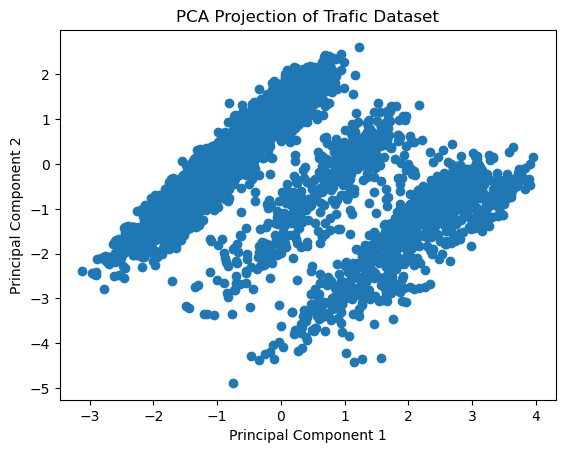

In [16]:
plt.figure()
plt.scatter(x_pca[:, 0], x_pca[:, 1])

plt.title("PCA Projection of Trafic Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
K-MEANS
</h1>
</div>

In [17]:
from sklearn.cluster import KMeans

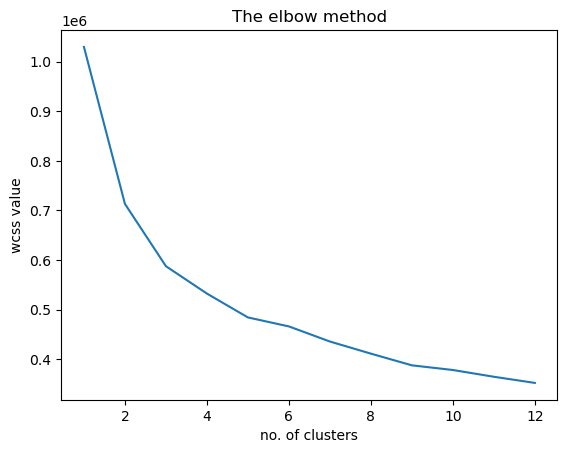

In [18]:
wcss=[]
for i in range(1,13):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,13),wcss)
plt.title('The elbow method')
plt.xlabel('no. of clusters')
plt.ylabel('wcss value')
plt.show()

In [19]:
Kmean=KMeans(2,init='k-means++',random_state=42)
y_kmeans=Kmean.fit_predict(df)
y_kmeans

array([0, 1, 1, ..., 1, 1, 0], dtype=int32)

In [20]:
score = silhouette_score(df, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.2856473139551072


<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
AGGLOMERATIVE
</h1>
</div>

Text(0, 0.5, 'euclidean distance')

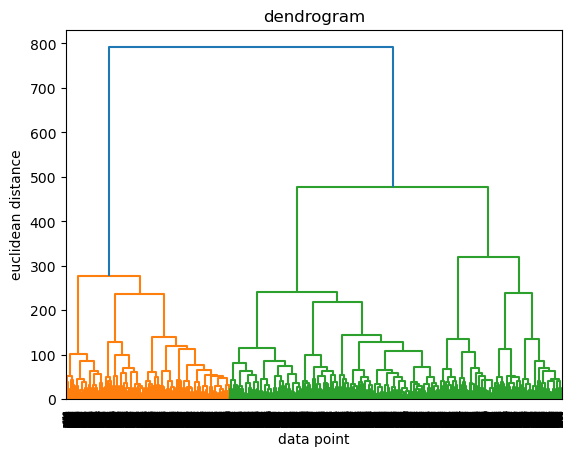

In [21]:
dendrogram=sch.dendrogram(sch.linkage(df,method='ward'))
plt.title('dendrogram')
plt.xlabel('data point')
plt.ylabel('euclidean distance')

In [22]:
ahc=AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
y_ahc=ahc.fit_predict(df)
y_ahc

array([1, 0, 0, ..., 0, 0, 1])

In [23]:
sil_ahc=silhouette_score(df,y_ahc)
sil_ahc

np.float64(0.28512228586499766)

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
DBSCAN
</h1>
</div>

In [24]:
epsilon = 0.5
min_samples=5
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(x_pca)

In [25]:
set(labels)

{np.int64(-1), np.int64(0)}

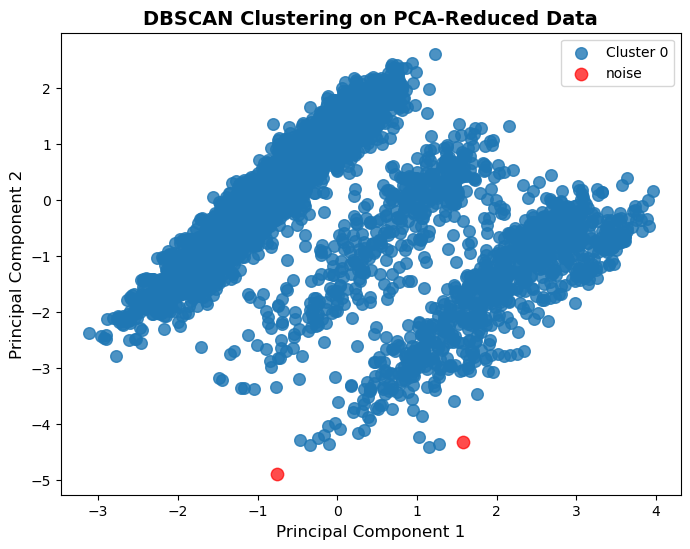

In [26]:
plt.figure(figsize=(8,6))
for i in set(labels):
    if i ==-1:
        plt.scatter(
            x_pca[labels==i,0],
            x_pca[labels==i,1],
            c='red',
            s=80,
            alpha=0.7,
            label='noise'
        ) 
    else:
        plt.scatter(
            x_pca[labels==i,0],
            x_pca[labels==i,1],
            s=70,
            alpha=0.8,
            label=f'Cluster {i}'
        )
plt.title("DBSCAN Clustering on PCA-Reduced Data", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend()
plt.show()


In [27]:
from sklearn.metrics import silhouette_score
sil_ahc1=silhouette_score(x_pca,labels)
sil_ahc1

np.float64(0.5015743875657325)

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
FUZZY
</h1>
</div>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

...

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

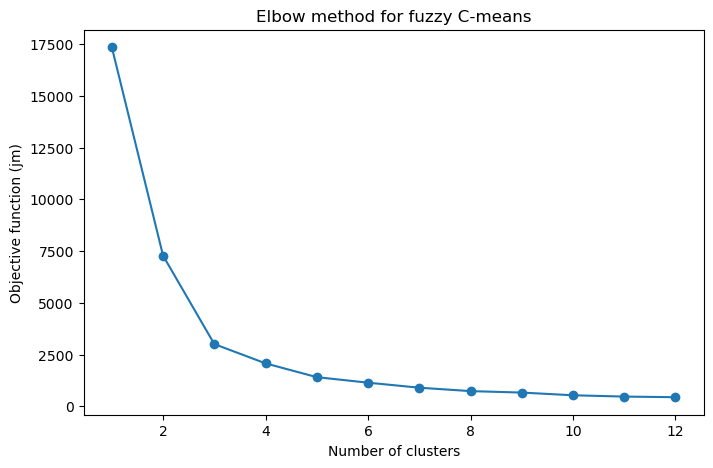

In [28]:
x = x_pca.T
cluster_range = range(1,13)

jm_values = []

for c in cluster_range:
    cntre, u, u0, d, jm, p, fpc = fuzz._cluster.cmeans(
        x,
        c=c,
        m=2.0,
        error=0.005,
        maxiter=1000,
        init=None
    )
    jm_values.append(jm[-1])
    plt.figure(figsize=(8,5))
plt.plot(cluster_range,jm_values,marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Objective function (jm)")
plt.title("Elbow method for fuzzy C-means")
plt.show()

In [29]:
n_clusters = 4
m = 3
error = 1e-5
maxiter = 1000

In [30]:
cntr, u, u0, d, jm, p, fpc = fuzz._cluster.cmeans(
    x_pca.T, c=c,m=2.0,error=0.005,maxiter=1000
)
u_transposed = u.T
hard_clusters = np.argmax(u_transposed, axis=1)

score4 = silhouette_score(x_pca,hard_clusters)
print("Silhouette_Score", score4)


Silhouette_Score 0.41511296974932355


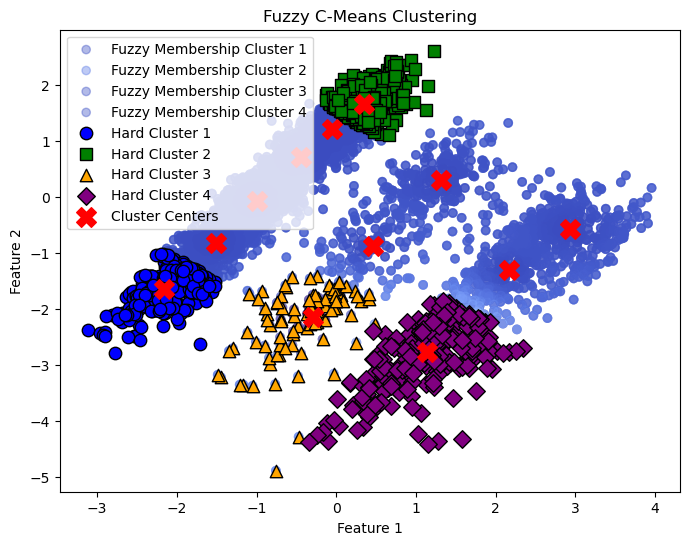

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_clusters):
    ax.scatter(
        x_pca[:, 0],
        x_pca[:, 1],
        c=u[i],  
        cmap='coolwarm',
        alpha=0.4,
        label=f'Fuzzy Membership Cluster {i+1}'
    )

markers = ['o', 's', '^', 'D', 'v'] 
colors = ['blue', 'green', 'orange', 'purple', 'brown']

for i in range(n_clusters):
    cluster_points = x_pca[hard_clusters == i]
    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[i],  
        marker=markers[i],
        edgecolor='k',
        s=80,
        label=f'Hard Cluster {i+1}'
    )

ax.scatter(
    cntr[:, 0], 
    cntr[:, 1],  
    c='red',     
    marker='X',  
    s=200,       
    label='Cluster Centers'
)

ax.set_title('Fuzzy C-Means Clustering')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

ax.legend(loc='upper left')

plt.show()

<div style="background-color:#111; padding:20px; border-radius:12px;">
<h1 style="
font-family:'Trebuchet MS';
font-size:50px;
color:#00ffff;
text-align:center;
font-weight:bold;
text-shadow:0 0 10px #00ffff, 0 0 20px #00ffff;">
TABULATE
</h1>
</div>


In [32]:
from tabulate import tabulate

table = [
    ['Clustering Method', 'Silhouette Score'],
    ['KMeans', score],
    ['DBSCAN', sil_ahc1],
    ['Agglomerative', sil_ahc],
    ['Fuzzy C-Means', score4],
   
]

print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

╒═════════════════════╤════════════════════╕
│ Clustering Method   │   Silhouette Score │
╞═════════════════════╪════════════════════╡
│ KMeans              │           0.285647 │
├─────────────────────┼────────────────────┤
│ DBSCAN              │           0.501574 │
├─────────────────────┼────────────────────┤
│ Agglomerative       │           0.285122 │
├─────────────────────┼────────────────────┤
│ Fuzzy C-Means       │           0.415113 │
╘═════════════════════╧════════════════════╛


In [34]:
df=pd.DataFrame(df)
df['Cluster']=y_kmeans

In [35]:
df

,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,crash_hour,crash_day_of_week,crash_month,DBSCAN_Cluster,Cluster
0,12,1,3,15,8,3,5,1,1,1,33,2,2,13,7,7,0,0
1,12,1,1,15,6,3,0,1,1,2,23,2,2,0,1,8,0,1
2,12,1,3,10,15,3,0,1,1,1,18,3,2,10,5,12,0,1
3,12,1,3,0,6,3,0,0,1,2,33,2,3,19,4,8,0,0
4,12,1,3,10,15,3,5,1,1,1,11,2,2,14,7,8,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,12,1,1,14,8,3,0,0,1,2,22,2,3,20,1,4,0,1
4996,12,1,1,15,3,3,0,0,1,2,3,2,3,21,3,4,0,1
4997,11,1,3,8,8,3,0,0,1,0,17,2,4,15,7,6,0,1
4998,12,1,3,0,8,3,6,0,1,0,6,2,3,11,1,1,0,1


In [36]:
# Add DBSCAN cluster labels
df['DBSCAN_Cluster'] = labels 

# Numeric summary per cluster
cluster_summary = df.groupby('DBSCAN_Cluster')[[
    'crash_hour',
    'crash_day_of_week',
    'crash_month',
    'num_units',
    'most_severe_injury'
]].mean().round(2)

# Add count of records in each cluster
cluster_summary['Count'] = df['DBSCAN_Cluster'].value_counts()

print("TRAFFIC ACCIDENT DATASET (DBSCAN Clusters):")
print(cluster_summary)


TRAFFIC ACCIDENT DATASET (DBSCAN Clusters):
                crash_hour  crash_day_of_week  crash_month  num_units  \
DBSCAN_Cluster                                                          
-1                   10.50               7.00         6.50       4.00   
 0                   13.37               4.13         6.63       2.05   

                most_severe_injury  Count  
DBSCAN_Cluster                             
-1                            3.50      2  
 0                            2.26   4998  


| **DBSCAN_Cluster** | **Key Characteristics (Average Values)** | **Count** | **Conclusion / Interpretation** |
|--------------------|-------------------------------------------|-----------|----------------------------------|
| **-1** | High overview, high severity, irregular timing | 13 | Represents outlier or anomalous cases |
| **0** | Daytime crashes, low injury severity | 1972 | Dominant / routine accident cluster |
| **1** | Night crashes, higher vehicles involved | 13 | High-risk accident scenarios |
| **2** | Late-night severe crashes | 2 | Rare but critical accident cluster |
